<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Deep_Neura_Fundamentos_Imagens_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

In [8]:
!wget -q https://cloudfront-us-east-1.images.arcpublishing.com/estadao/5B4KXIIJVRGIBNRMAILCOGYQN4.jpg

In [9]:
img_path = '5B4KXIIJVRGIBNRMAILCOGYQN4.jpg'
img = Image.open(img_path)

In [10]:
img_res = img.resize((224, 224))
img_array = np.array(img_res)

In [11]:
canal_r = img_array[:, :, 0]
canal_g = img_array[:, :, 1]
canal_b = img_array[:, :, 2]

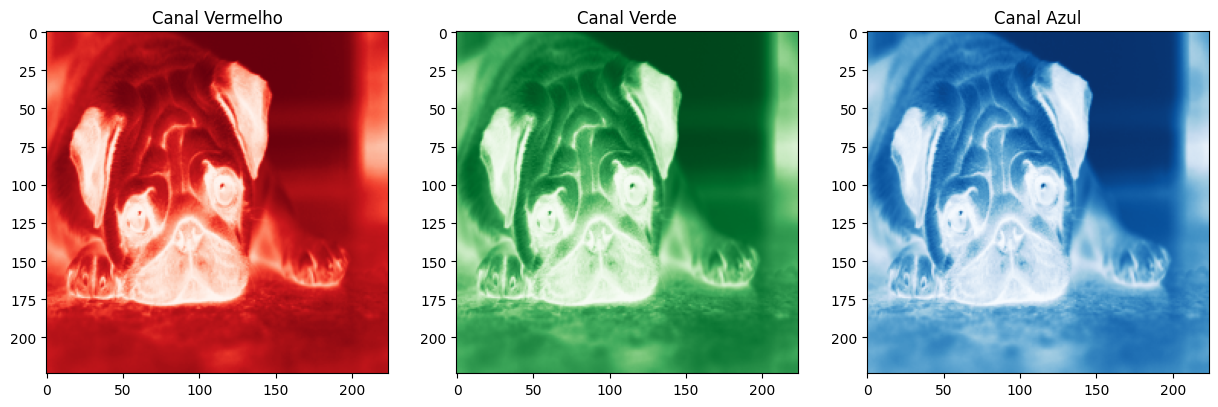

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(canal_r, cmap='Reds')
axs[0].set_title("Canal Vermelho")
axs[1].imshow(canal_g, cmap='Greens')
axs[1].set_title("Canal Verde")
axs[2].imshow(canal_b, cmap='Blues')
axs[2].set_title("Canal Azul")
plt.show()

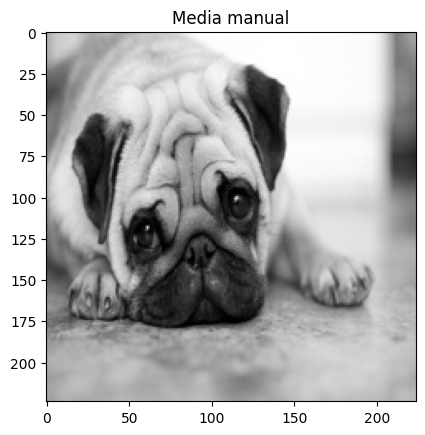

In [13]:
img_gray = np.mean(img_array, axis=2)
plt.imshow(img_gray, cmap='gray')
plt.title("Media manual")
plt.show()

In [14]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [15]:
transformacao = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [16]:
fmnist_treino = datasets.FashionMNIST('~/data/FMNIST', train=True, download=True, transform=transformacao)
treino_loader = DataLoader(fmnist_treino, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.03MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 132kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.42MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.23MB/s]


In [17]:
imagens, rotulos = next(iter(treino_loader))

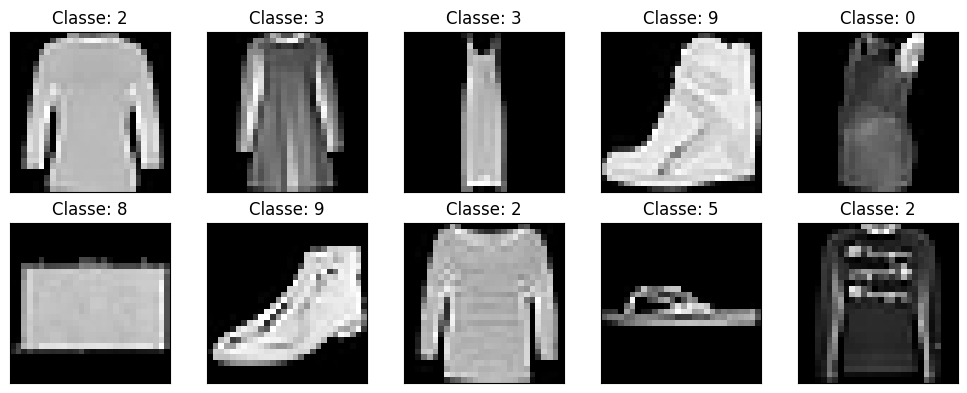

In [18]:
fig = plt.figure(figsize=(10, 4))
for i in range(10): # mostra os 10 primeiros do batch
    ax = fig.add_subplot(2, 5, i+1, xticks=[], yticks=[])
    ax.imshow(imagens[i].numpy().squeeze(), cmap='gray')
    ax.set_title(f"Classe: {rotulos[i].item()}")

plt.tight_layout()
plt.show()

In [20]:
print(f"Total {len(treino_loader)}")
print(f"formato do tensor:{imagens.shape}")

Total 938
formato do tensor:torch.Size([64, 1, 28, 28])


In [22]:
import torch
import torch.nn as nn
from torch.optim import Adam  # otimizador alterado era RMSprop

In [23]:
class RedeNeuralCustom(nn.Module):
    def __init__(self):
        super().__init__()
        self.sequencial = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.BatchNorm1d(256),          # valor alterado era 512
            nn.ReLU(),
            nn.Dropout(0.3),              # camada nova adicionada
            nn.Linear(256, 64),           # valor alterado era 128
            nn.ReLU(),
            nn.Linear(64, 10)
        )
    def forward(self, x):
        x = x.view(-1, 28 * 28)
        return self.sequencial(x)

In [24]:
model = RedeNeuralCustom()

In [25]:
optimizer = Adam(model.parameters(), lr=0.0007)  # valor alterado (era 0.001 com RMSprop)
loss_fn = nn.CrossEntropyLoss()
model

RedeNeuralCustom(
  (sequencial): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [26]:
input_teste = torch.randn(1, 28, 28)
model.eval()
output = model(input_teste)
output.shape

torch.Size([1, 10])

In [27]:
model.train()

RedeNeuralCustom(
  (sequencial): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)